# About Dataset:
RowNumber—corresponds to the record (row) number and has no effect on the output.

CustomerId—contains random values and has no effect on customer leaving the bank.

Surname—the surname of a customer has no impact on their decision to leave the bank.

CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.

Geography—a customer’s location can affect their decision to leave the bank.

Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.

Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.

Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.

Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.

NumOfProducts—refers to the number of products that a customer has purchased through the bank.

HasCrCard—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.

IsActiveMember—active customers are less likely to leave the bank.

EstimatedSalary—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
Exited—whether or not the customer left the bank.

Complain—customer has complaint or not.

Satisfaction Score—Score provided by the customer for their complaint resolution.
Card Type—type of card hold by the customer.

Points Earned—the points earned by the customer for using credit card.

## Acknowledgements
As we know, it is much more expensive to sign in a new client than keeping an existing one.
It is advantageous for banks to know what leads a client towards the decision to leave the company.
Churn prevention allows companies to develop loyalty programs and retention campaigns to keep as many customers as possible.

In [1]:
# pasos 1, importar as bibliotcas e os dados

import pandas as pd
import numpy as np
import catboost as cb
import os

trainPath = r'C:\Users\Rafael\OneDrive - UNIOESTE\Documentos\Estudo Analise de dados - Keggle\bank-customer-churn-ict-u-ai\train.csv'

tabelaTreino = pd.read_csv(trainPath)

tabelaTreino.shape

tabelaTreino.info()

# passos 2, tratar os dados

#tabelaTreino = tabelaTreino.drop(columns=['id', 'CustomerId', 'Surname'])

tabelaTreino.info()



Categoricos = ['Geography', 
               'Gender',
               'Tenure',
               'NumOfProducts',
               'HasCrCard',
               'IsActiveMember',]

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# paso 3, analise de dados iniciais
import plotly.express as px

for coluna in tabelaTreino.columns:
    if coluna != 'Exited' and coluna != 'id' and coluna != 'CustomerId' and coluna != 'Surname':  # Pular a coluna Exited
        grafico = px.histogram(tabelaTreino, x=coluna, color='Exited', title=coluna)
        grafico.show()

        # Criar tabela cruzada normalizada por linha (100% por categoria)
        dados = pd.crosstab(tabelaTreino[coluna], tabelaTreino['Exited'], normalize='index') * 100
        dados = dados.reset_index().melt(id_vars=coluna)
        dados.columns = [coluna, 'Exited', 'Percentage']
        
        # Criar gráfico com porcentagens
        grafico = px.bar(dados, x=coluna, y='Percentage', color='Exited', 
                        barmode='group', title=coluna,
                        labels={'Percentage': 'Porcentagem (%)', 'Exited': 'Cancelou'},
                        text='Percentage')
        grafico.update_traces(textposition='auto', texttemplate='%{text:.1f}%')

        grafico.show()

        grafico = px.line(dados, x=coluna, y='Percentage', color='Exited',title=coluna)
        grafico.show()

In [ ]:
# Codificar as variáveis categóricas usando Label Encoding
from sklearn.preprocessing import LabelEncoder

codificador = LabelEncoder()

tabelaTreino_codif = tabelaTreino.copy()

# só não aplicamos na coluna score_credito que é o nosso objetivo (y || f(x)), ou seja, a variável que queremos prever
for coluna in tabelaTreino_codif.columns:
    if tabelaTreino_codif[coluna].dtype == 'str' and coluna != 'Exited':
        tabelaTreino_codif[coluna] = codificador.fit_transform(tabelaTreino_codif[coluna])


In [ ]:
# passo 4: seprar as partes da tabela para treino e teste

from sklearn.model_selection import train_test_split

# Separando as variáveis independentes de y
X = tabelaTreino_codif.drop(columns=['id', 'CustomerId', 'Surname', 'Exited']) # Variáveis independentes (todas as colunas, exceto 'Exited')

# Separando a variável dependente (y - O diagnóstico real)
y = tabelaTreino_codif['Exited']

# Verificando as separações
print("Formato do X (Variáveis):", X.shape)
print("Formato do y (Target):", y.shape)

# Calcula a porcentagem de cada classe dentro de y
proporcoes = y.value_counts(normalize=True) * 100

print("Proporção das classes no dataset:")
print(proporcoes)

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.15, stratify=y)

print("Pacientes para o modelo estudar (X_train):", x_treino.shape)
print("Pacientes para o modelo testar (X_test):", x_teste.shape)

#antes de treinar o modelo, precisamos fazer um feature selection, ou seja, selecionar as variáveis mais importantes para o modelo


Formato do X (Variáveis): (15000, 10)
Formato do y (Target): (15000,)
Proporção das classes no dataset:
Exited
0.0    79.513333
1.0    20.486667
Name: proportion, dtype: float64
Pacientes para o modelo estudar (X_train): (12750, 10)
Pacientes para o modelo testar (X_test): (2250, 10)


<Axes: >

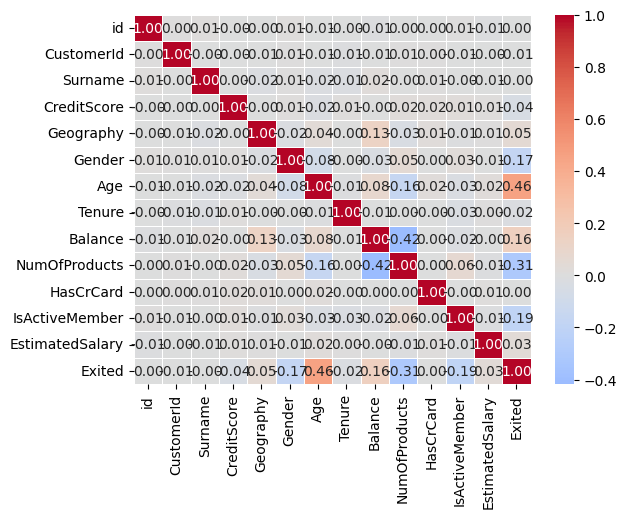

In [ ]:
# Criar uma tabela cruzada normalizada por linha (100% por categoria) para descobrir a correlação entre as variaveis
# com o objetivo de descobrir quais variáveis tem mais correlação com a variável alvo (Exited) e quais variáveis tem mais correlação entre si, para depois fazer um feature selection, ou seja, selecionar as variáveis mais importantes para o modelo

import seaborn as sns

sns.heatmap(tabelaTreino_codif.corr(), annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt = '.2f')

In [ ]:
# Passo 3 - treinar a máquina
# Criar o modelo: Nota de crédito: Boa, Ok, Ruim

# Arvore de decisão -> Random Forest
# Nearest Neighbor -> KNN -> Vizinhos próximos

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Criar o modelo
modelo_arvoredecisao = RandomForestClassifier()
modelo_knn = KNeighborsClassifier()

# Treinar o modelo
modelo_arvoredecisao.fit(x_treino, y_treino)
modelo_knn.fit(x_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# Passo 4 - Escolher qual o melhor modelo

# Calcular as previsões dos modelos
previsao_arvore = modelo_arvoredecisao.predict(x_teste)
previsao_knn = modelo_knn.predict(x_teste)

from sklearn.metrics import accuracy_score

# Calcular a acurácia dos modelos comparando as previsões com os valores reais
display(accuracy_score(y_teste, previsao_arvore))
display(accuracy_score(y_teste, previsao_knn))

0.8768888888888889

0.7582222222222222